# 🔐 RSA 암호 구조 이해하기

**RSA**(Rivest–Shamir–Adleman)는 1977년에 발표된 **공개키 암호 시스템**으로, 현대 인터넷 보안의 근간을 이루고 있습니다.

이 노트북에서는 RSA의 핵심 수학적 원리부터 실제 구현까지 단계별로 살펴봅니다.

### 📋 목차
1. 필요 라이브러리 임포트
2. 두 개의 큰 소수 $p$, $q$ 생성
3. $n$과 $\phi(n)$ 계산
4. 공개 지수 $e$와 개인 지수 $d$ 계산
5. 메시지 암호화 및 복호화 테스트
6. RSA 서명과 검증
7. 시각화 — 그래프로 보는 RSA
8. 문자열 메시지 암호화 실습
9. 요약

## 📦 1. 필요 라이브러리 임포트

RSA 구현에 필요한 도구들을 불러옵니다.

- **`sympy`**: 소수 생성, 소수 판별, 확장 유클리드 알고리즘 등 수학적 기능
- **`random`**: 난수 생성
- **`math`**: 기본 수학 함수
- **`matplotlib`**: 시각화

In [9]:
# 필요 라이브러리 임포트
import sympy as sp
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'AppleGothic'
except:
    plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
# emoji 등을 위해 폰트 fallback 처리
plt.rcParams['font.size'] = 11

print("✅ 라이브러리 임포트 완료!")
print(f"SymPy version: {sp.__version__}")

✅ 라이브러리 임포트 완료!
SymPy version: 1.14.0


## 🔢 2. 두 개의 큰 소수 $p$, $q$ 생성

RSA의 안전성은 **큰 수의 소인수분해가 어렵다**는 사실에 기반합니다.

- 두 개의 **큰 소수** $p$와 $q$를 선택합니다.
- 이들은 **비밀**로 보관됩니다.
- 실제 RSA에서는 1024~4096비트 크기의 소수를 사용합니다.

### 수학적 배경: 페르마의 소정리

소수 $p$와 $p$의 배수가 아닌 정수 $a$에 대해:

$$a^{p-1} \equiv 1 \ (\text{mod } p)$$

이 정리가 RSA 복호화가 올바르게 동작하는 이유를 설명합니다.

p = 39703  (비트 수: 16비트)
q = 64763  (비트 수: 16비트)
p가 소수인가? True
q가 소수인가? True


/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/4275891401.py:30: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) AppleGothic.
  plt.tight_layout()


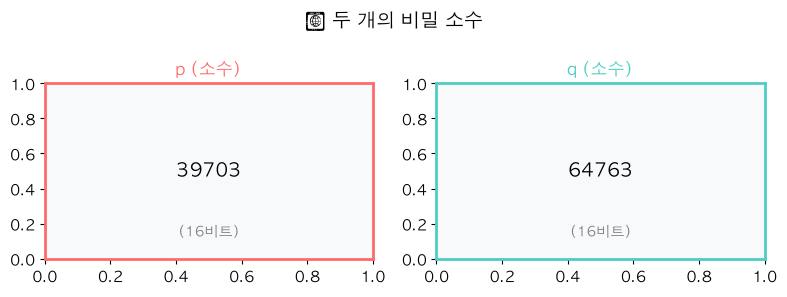

In [10]:
# 소수 생성 함수
def generate_large_prime(bits=16):
    """지정된 비트 수의 소수를 생성합니다."""
    prime = sp.randprime(2**(bits-1), 2**bits)
    return prime

# 16비트 소수 2개 생성 (실습용으로 작은 크기 사용)
# 실제 RSA는 1024~4096비트 사용
bits = 16
p = generate_large_prime(bits)
q = generate_large_prime(bits)

print(f"p = {p}  (비트 수: {p.bit_length()}비트)")
print(f"q = {q}  (비트 수: {q.bit_length()}비트)")
print(f"p가 소수인가? {sp.isprime(p)}")
print(f"q가 소수인가? {sp.isprime(q)}")

# 시각화: p와 q를 네모로 표현
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, val, label, color in zip(axes, [p, q], ['p (소수)', 'q (소수)'], ['#FF6B6B', '#4ECDC4']):
    ax.text(0.5, 0.5, str(val), ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(0.5, 0.15, f'({val.bit_length()}비트)', ha='center', va='center', fontsize=10, color='gray')
    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_facecolor('#f8f9fa')
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(2)
plt.suptitle('🔑 두 개의 비밀 소수', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧮 3. $n$과 $\phi(n)$ 계산

$p$와 $q$로부터 두 중요한 값을 계산합니다:

### $n = p \times q$
- **공개되는 값** (공개키의 일부)
- 암호화와 복호화 모두에 사용되는 **모듈러스(modulus)**

### $\phi(n) = (p-1)(q-1)$
- **비밀로 유지되는 값**
- 오일러 피 함수(Euler's totient function)
- $n$보다 작고 $n$과 서로소인 양의 정수의 개수
- $\phi(n)$을 알아야 개인키 $d$를 계산할 수 있음

🔹 n = p × q
   n = 39703 × 64763
   n = 2571285389
   (비트 수: 32비트)

🔹 φ(n) = (p-1) × (q-1)
   φ(n) = 39702 × 64762
   φ(n) = 2571180924



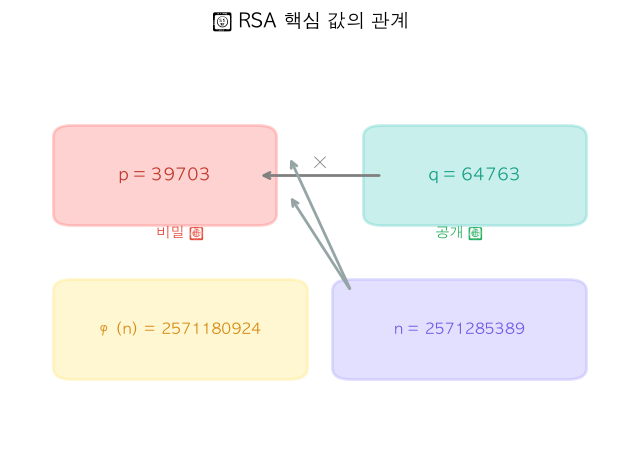

In [11]:
# n과 phi(n) 계산
n = p * q
phi_n = (p - 1) * (q - 1)

print(f"🔹 n = p × q")
print(f"   n = {p} × {q}")
print(f"   n = {n}")
print(f"   (비트 수: {n.bit_length()}비트)")
print()
print(f"🔹 φ(n) = (p-1) × (q-1)")
print(f"   φ(n) = {p-1} × {q-1}")
print(f"   φ(n) = {phi_n}")
print()

# RSA 관계 시각화
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')

# p, q 박스
ax.add_patch(mpatches.FancyBboxPatch((1, 6), 3, 2, boxstyle="round,pad=0.3", 
                                       facecolor='#FF6B6B', alpha=0.3, edgecolor='#FF6B6B', linewidth=2))
ax.text(2.5, 7, f'p = {p}', ha='center', va='center', fontsize=12, fontweight='bold', color='#c0392b')

ax.add_patch(mpatches.FancyBboxPatch((6, 6), 3, 2, boxstyle="round,pad=0.3", 
                                       facecolor='#4ECDC4', alpha=0.3, edgecolor='#4ECDC4', linewidth=2))
ax.text(7.5, 7, f'q = {q}', ha='center', va='center', fontsize=12, fontweight='bold', color='#16a085')

# 연산 결과 박스
ax.add_patch(mpatches.FancyBboxPatch((1, 2), 3.5, 2, boxstyle="round,pad=0.3", 
                                       facecolor='#FFE66D', alpha=0.3, edgecolor='#FFE66D', linewidth=2))
ax.text(2.75, 3, f'φ(n) = {phi_n}', ha='center', va='center', fontsize=11, fontweight='bold', color='#d68910')

ax.add_patch(mpatches.FancyBboxPatch((5.5, 2), 3.5, 2, boxstyle="round,pad=0.3", 
                                       facecolor='#A29BFE', alpha=0.3, edgecolor='#A29BFE', linewidth=2))
ax.text(7.25, 3, f'n = {n}', ha='center', va='center', fontsize=11, fontweight='bold', color='#6c5ce7')

# 화살표
ax.annotate('', xy=(4, 7), xytext=(6, 7), arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(4.5, 6.5), xytext=(5.5, 4), arrowprops=dict(arrowstyle='->', lw=2, color='#95a5a6'))
ax.annotate('', xy=(4.5, 7.5), xytext=(5.5, 4), arrowprops=dict(arrowstyle='->', lw=2, color='#95a5a6'))

# 화살표 레이블
ax.text(5, 7.3, '×', ha='center', va='center', fontsize=16, fontweight='bold', color='gray')
ax.text(2.75, 5.5, '비밀 🔒', ha='center', va='center', fontsize=10, color='#e74c3c')
ax.text(7.25, 5.5, '공개 🔓', ha='center', va='center', fontsize=10, color='#27ae60')

plt.suptitle('🧮 RSA 핵심 값의 관계', fontsize=14, fontweight='bold', y=0.98)
plt.show()

## 🔑 4. 공개 지수 $e$와 개인 지수 $d$ 계산

### 공개키 지수 $e$ (암호화 키)
- 일반적으로 **$e = 65537$** 사용 (관례)
- 조건: $1 < e < \phi(n)$ 이고 $\gcd(e, \phi(n)) = 1$ (서로소)
- $65537$은 소수이고 $2^{16}+1$이라 계산 효율이 좋음

### 개인키 지수 $d$ (복호화 키)
- $d \equiv e^{-1} \pmod{\phi(n)}$, 즉 $e \times d \equiv 1 \pmod{\phi(n)}$
- **확장 유클리드 호제법**으로 계산
- $d$는 **절대 비밀로 유지**

### 핵심 관계식
$$E \times D = k \cdot \phi(n) + 1$$

이 관계식 덕분에 암호화 후 복호화하면 원문이 복원됩니다:
$$(A^E)^D \equiv A^{E \cdot D} \equiv A^{k \cdot \phi(n) + 1} \equiv A \pmod{n}$$

In [12]:
# 확장 유클리드 호제법으로 모듈러 역원 계산
def mod_inverse(e, phi):
    """확장 유클리드 호제법으로 e의 모듈러 역원 d를 계산합니다.
    즉, (e * d) % phi == 1 을 만족하는 d를 찾습니다."""
    def extended_gcd(a, b):
        if b == 0:
            return a, 1, 0
        g, x1, y1 = extended_gcd(b, a % b)
        return g, y1, x1 - (a // b) * y1
    
    g, x, _ = extended_gcd(e, phi)
    if g != 1:
        raise ValueError("역원이 존재하지 않습니다.")
    return x % phi

# 공개 지수 e (일반적으로 65537 사용)
e = 65537

# e와 phi_n이 서로소인지 확인
g = math.gcd(e, phi_n) if hasattr(math, 'gcd') else sp.gcd(e, phi_n)
print(f"🔍 gcd(e, φ(n)) = gcd({e}, {phi_n}) = {g}")
print(f"   → {'✅ 서로소: e 사용 가능' if g == 1 else '❌ 다른 e를 선택해야 함'}")

if g != 1:
    # 드문 경우지만 서로소가 아니면 다른 e 선택
    for candidate in [3, 5, 17, 257]:
        if math.gcd(candidate, phi_n) == 1:
            e = candidate
            break

# 개인 지수 d 계산
d = mod_inverse(e, phi_n)

print(f"\n🔑 공개키 지수 e = {e}")
print(f"🔐 개인키 지수 d = {d}")
print()

# 검증: e * d ≡ 1 (mod phi_n)
verify = (e * d) % phi_n
print(f"✅ 검증: (e × d) mod φ(n) = ({e} × {d}) mod {phi_n} = {verify}")
print(f"   → {'✅ 일치함!' if verify == 1 else '❌ 불일치!'}")

# 공개키 / 개인키 요약
print(f"\n📋 ====== 키 요약 =====")
print(f"🔓 공개키  (n, e) = ({n}, {e})")
print(f"🔒 개인키  (n, d) = ({n}, {d})")
print(f"=======================")

🔍 gcd(e, φ(n)) = gcd(65537, 2571180924) = 1
   → ✅ 서로소: e 사용 가능

🔑 공개키 지수 e = 65537
🔐 개인키 지수 d = 1372196225

✅ 검증: (e × d) mod φ(n) = (65537 × 1372196225) mod 2571180924 = 1
   → ✅ 일치함!

📋 ====== 키 요약 =====
🔓 공개키  (n, e) = (2571285389, 65537)
🔒 개인키  (n, d) = (2571285389, 1372196225)


## ✉️ 5. 메시지 암호화 및 복호화 테스트

드디어 RSA 암호화/복호화를 테스트합니다!

### 암호화 (송신자)
$$C = M^E \bmod N$$

### 복호화 (수신자)
$$M = C^D \bmod N$$

> 💡 **핵심**: $E$와 $N$은 공개되어 누구나 암호화할 수 있지만, $D$를 아는 수신자만 복호화할 수 있습니다.

📝 원본 메시지 M = 42
   (M < n 이어야 함: 42 < 2571285389 → ✅ 가능)

🔒 암호문 C = 42^65537 mod 2571285389
   C = 1914090616

🔓 복호문 = 1914090616^1372196225 mod 2571285389
   복호문 = 42

✅ 검증 결과: 성공! 원문 복원됨! 🎉


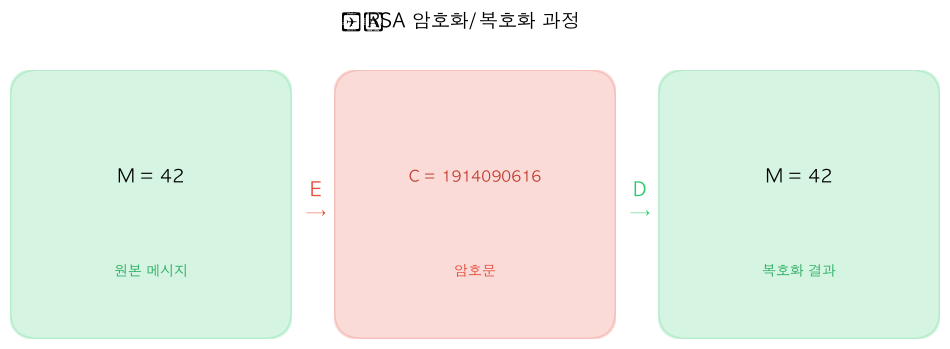

In [13]:
# RSA 암호화/복호화 함수
def rsa_encrypt(message, e, n):
    """RSA 암호화: C = M^e mod n"""
    return pow(message, e, n)

def rsa_decrypt(cipher, d, n):
    """RSA 복호화: M = C^d mod n"""
    return pow(cipher, d, n)

# 테스트할 평문 메시지 (n보다 작아야 함)
original_message = 42  # 임의의 숫자
print(f"📝 원본 메시지 M = {original_message}")
print(f"   (M < n 이어야 함: {original_message} < {n} → {'✅ 가능' if original_message < n else '❌ 너무 큼'})")

# 암호화
cipher = rsa_encrypt(original_message, e, n)
print(f"\n🔒 암호문 C = {original_message}^{e} mod {n}")
print(f"   C = {cipher}")

# 복호화
decrypted = rsa_decrypt(cipher, d, n)
print(f"\n🔓 복호문 = {cipher}^{d} mod {n}")
print(f"   복호문 = {decrypted}")

# 검증
print(f"\n{'='*50}")
print(f"✅ 검증 결과: {'성공! 원문 복원됨! 🎉' if original_message == decrypted else '실패!'}")
print(f"{'='*50}")

# 단계별 시각화
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.5))

# 원본
ax1.add_patch(mpatches.FancyBboxPatch((0.1, 0.1), 0.8, 0.8, boxstyle="round,pad=0.1",
                                       facecolor='#2ecc71', alpha=0.2, edgecolor='#2ecc71', linewidth=2))
ax1.text(0.5, 0.6, f'M = {original_message}', ha='center', va='center', fontsize=13, fontweight='bold')
ax1.text(0.5, 0.25, '원본 메시지', ha='center', va='center', fontsize=10, color='#27ae60')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')

# 암호문
ax2.add_patch(mpatches.FancyBboxPatch((0.1, 0.1), 0.8, 0.8, boxstyle="round,pad=0.1",
                                       facecolor='#e74c3c', alpha=0.2, edgecolor='#e74c3c', linewidth=2))
ax2.text(0.5, 0.6, f'C = {cipher}', ha='center', va='center', fontsize=11, fontweight='bold', color='#c0392b')
ax2.text(0.5, 0.25, '암호문', ha='center', va='center', fontsize=10, color='#e74c3c')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')

# 복호문
ax3.add_patch(mpatches.FancyBboxPatch((0.1, 0.1), 0.8, 0.8, boxstyle="round,pad=0.1",
                                       facecolor='#2ecc71', alpha=0.2, edgecolor='#2ecc71', linewidth=2))
ax3.text(0.5, 0.6, f'M = {decrypted}', ha='center', va='center', fontsize=13, fontweight='bold')
ax3.text(0.5, 0.25, '복호화 결과', ha='center', va='center', fontsize=10, color='#27ae60')
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis('off')

# 화살표
plt.subplots_adjust(wspace=0.15)
fig.text(0.38, 0.5, '  E  \n→', ha='center', va='center', fontsize=14, fontweight='bold', color='#e74c3c')
fig.text(0.65, 0.5, '  D  \n→', ha='center', va='center', fontsize=14, fontweight='bold', color='#2ecc71')

plt.suptitle('✉️ RSA 암호화/복호화 과정', fontsize=14, fontweight='bold', y=1.05)
plt.show()

## ✍️ 6. RSA 서명과 검증

RSA는 암호화뿐 아니라 **디지털 서명**에도 사용됩니다.

### 서명 (송신자, 개인키 사용)
$$S = M^D \bmod N$$

### 검증 (수신자, 공개키 사용)
$$M = S^E \bmod N$$

> 💡 암호화는 **공개키**로 하고 복호화는 **개인키**로 하지만, 서명은 반대입니다: **개인키**로 서명하고 **공개키**로 검증합니다.

📄 문서 번호: 123
✍️  서명 값 S = 123^1372196225 mod 2571285389
   S = 1973046770

🔍 검증 결과: 123
   문서 복원: ✅ 서명 검증 성공! 🎉

🚨 변조된 서명 검증: 956187914
   → 변조 검출: ✅ 위조 감지!


/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/3901784370.py:47: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/3901784370.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/3901784370.py:47: UserWarning: Glyph 9997 (\N{WRITING HAND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/3901784370.py:47: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) AppleGothic.
  plt.tight_layout()


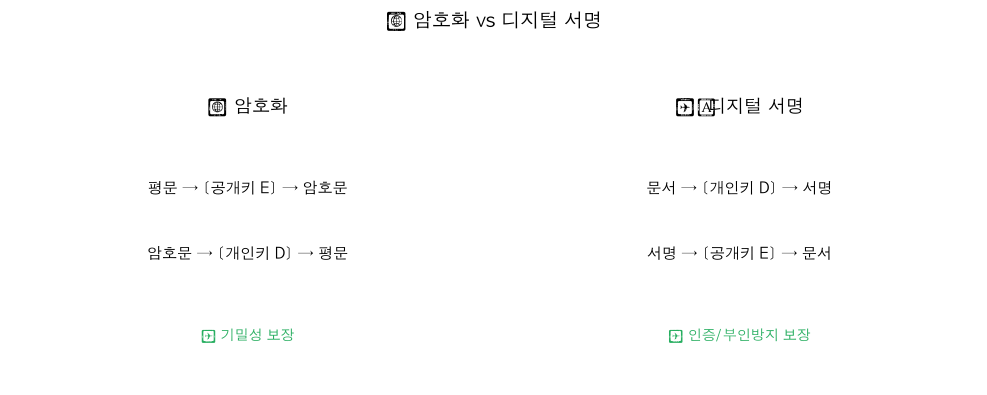

In [14]:
# RSA 서명 함수
def rsa_sign(message, d, n):
    """RSA 서명: S = M^d mod n (개인키로 서명)"""
    return pow(message, d, n)

def rsa_verify(signature, e, n):
    """RSA 서명 검증: M = S^e mod n (공개키로 검증)"""
    return pow(signature, e, n)

# 서명 테스트
doc = 123  # 서명할 문서 번호
signature = rsa_sign(doc, d, n)
verified = rsa_verify(signature, e, n)

print(f"📄 문서 번호: {doc}")
print(f"✍️  서명 값 S = {doc}^{d} mod {n}")
print(f"   S = {signature}")
print(f"\n🔍 검증 결과: {verified}")
print(f"   문서 복원: {'✅ 서명 검증 성공! 🎉' if verified == doc else '❌ 서명 위조 감지!'}")

# 변조된 서명 검증 테스트
forged_signature = signature + 1  # 서명 변조
forged_verified = rsa_verify(forged_signature, e, n)
print(f"\n🚨 변조된 서명 검증: {forged_verified}")
print(f"   → 변조 검출: {'✅ 위조 감지!' if forged_verified != doc else '❌ 위조 미감지 (문제!)'}")

# 암호화 vs 서명 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 암호화 다이어그램
ax1.text(0.5, 0.85, '🔒 암호화', ha='center', va='center', fontsize=13, fontweight='bold')
ax1.text(0.5, 0.6, '평문 → [공개키 E] → 암호문', ha='center', va='center', fontsize=11)
ax1.text(0.5, 0.4, '암호문 → [개인키 D] → 평문', ha='center', va='center', fontsize=11)
ax1.text(0.5, 0.15, '✅ 기밀성 보장', ha='center', va='center', fontsize=10, color='#27ae60')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')
ax1.set_facecolor('#e8f8f5')

# 서명 다이어그램
ax2.text(0.5, 0.85, '✍️  디지털 서명', ha='center', va='center', fontsize=13, fontweight='bold')
ax2.text(0.5, 0.6, '문서 → [개인키 D] → 서명', ha='center', va='center', fontsize=11)
ax2.text(0.5, 0.4, '서명 → [공개키 E] → 문서', ha='center', va='center', fontsize=11)
ax2.text(0.5, 0.15, '✅ 인증/부인방지 보장', ha='center', va='center', fontsize=10, color='#27ae60')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
ax2.set_facecolor('#fef9e7')

plt.suptitle('🔄 암호화 vs 디지털 서명', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 7. 시각화 — 그래프로 보는 RSA

RSA 암호화 함수 $f(x) = x^E \bmod N$의 성질을 그래프로 확인합니다.

- 암호화는 **일대일 함수** (서로 다른 입력은 서로 다른 출력)
- 주기적이고 복잡한 패턴 → 역함수($D$ 없이)를 찾기 어려움을 직관적으로 이해

/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/2392732350.py:29: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/6d/snh7_c_j3t74f19lml5h_57c0000gn/T/ipykernel_98007/2392732350.py:29: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) AppleGothic.
  plt.tight_layout()


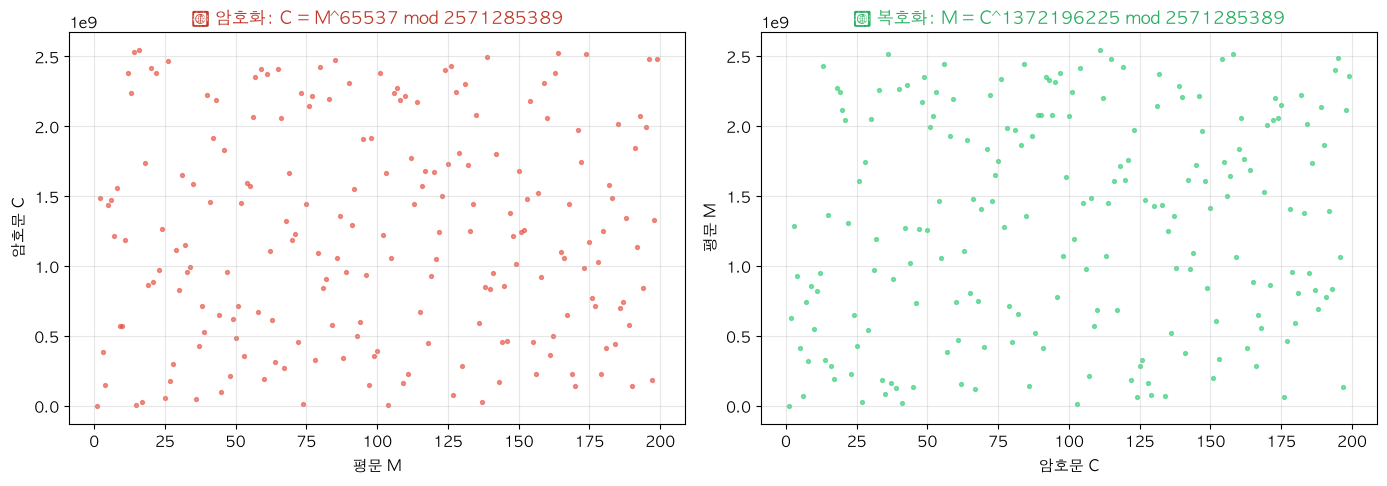

💡 암호화 그래프는 복잡하게 흩어져 있어 e만으로는 역산이 어렵습니다.
💡 복호화 그래프는 일정한 패턴을 보이며 d를 알면 정확히 원문을 복원할 수 있습니다.


In [15]:
# RSA 함수 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# x값 범위 (0 ~ n-1)
x_vals = list(range(1, min(n, 200)))  # n이 너무 크면 200개로 제한

# 암호화: E(x) = x^e mod n
y_enc = [pow(x, e, n) for x in x_vals]

# 복호화: D(x) = x^d mod n
y_dec = [pow(x, d, n) for x in x_vals]

# 암호화 그래프
ax1 = axes[0]
ax1.scatter(x_vals, y_enc, s=8, c='#e74c3c', alpha=0.6)
ax1.set_xlabel('평문 M', fontsize=11)
ax1.set_ylabel('암호문 C', fontsize=11)
ax1.set_title(f'🔒 암호화: C = M^{e} mod {n}', fontsize=12, fontweight='bold', color='#c0392b')
ax1.grid(True, alpha=0.3)

# 복호화 그래프
ax2 = axes[1]
ax2.scatter(x_vals, y_dec, s=8, c='#2ecc71', alpha=0.6)
ax2.set_xlabel('암호문 C', fontsize=11)
ax2.set_ylabel('평문 M', fontsize=11)
ax2.set_title(f'🔓 복호화: M = C^{d} mod {n}', fontsize=12, fontweight='bold', color='#27ae60')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 암호화 그래프는 복잡하게 흩어져 있어 e만으로는 역산이 어렵습니다.")
print("💡 복호화 그래프는 일정한 패턴을 보이며 d를 알면 정확히 원문을 복원할 수 있습니다.")

## 📝 8. 문자열 메시지 암호화 실습

실제 메시지(문자열)를 RSA로 암호화하고 복호화해 봅니다.

> ⚠️ **주의**: RSA는 블록 단위로 암호화하며, 한 번에 암호화할 수 있는 메시지 크기는 $n$ 비트 크기로 제한됩니다. 실제로는 RSA로 **대칭키(AES 등)를 교환**하고, 데이터는 AES로 암호화하는 **하이브리드 방식**을 사용합니다.

In [16]:
# 문자열을 정수로 변환 (ASCII → int)
def string_to_int(text):
    """문자열을 정수로 변환"""
    return int.from_bytes(text.encode('utf-8'), byteorder='big')

def int_to_string(number):
    """정수를 문자열로 변환"""
    try:
        return number.to_bytes((number.bit_length() + 7) // 8, byteorder='big').decode('utf-8')
    except:
        return f"[디코딩 불가: {number}]"

# 테스트할 메시지 (n보다 작은 길이여야 함)
msg = "AB!"
msg_int = string_to_int(msg)

print(f"📝 원본 메시지: '{msg}'")
print(f"🔢 정수 변환: {msg_int}")
print(f"   필요 비트: {msg_int.bit_length()}비트")
print(f"   n 크기: {n.bit_length()}비트")
print(f"   적합성: {'✅ 암호화 가능' if msg_int < n else '❌ 메시지가 너무 큼'}")

if msg_int < n:
    # 암호화
    cipher_int = rsa_encrypt(msg_int, e, n)
    print(f"\n🔒 암호화된 정수: {cipher_int}")
    
    # 복호화
    decrypted_int = rsa_decrypt(cipher_int, d, n)
    decrypted_msg = int_to_string(decrypted_int)
    
    print(f"🔓 복호화된 정수: {decrypted_int}")
    print(f"📄 복원된 메시지: '{decrypted_msg}'")
    print(f"\n{'='*50}")
    print(f"✅ {'메시지가 완벽히 복원되었습니다! 🎉' if msg == decrypted_msg else '오류 발생!'}")
    print(f"{'='*50}")

# 하이브리드 암호화 개념도
print(f"\n\n📋 실제 RSA 사용 방식 (하이브리드 암호화):")
print(f"   ┌─────────────────────────────────────────────┐")
print(f"   │  ① RSA: 대칭키(AES)를 안전하게 교환           │")
print(f"   │  ② AES: 실제 데이터를 빠르게 암호화/복호화     │")
print(f"   │  → RSA의 느린 속도를 AES의 빠른 속도로 보완    │")
print(f"   └─────────────────────────────────────────────┘")

📝 원본 메시지: 'AB!'
🔢 정수 변환: 4276769
   필요 비트: 23비트
   n 크기: 32비트
   적합성: ✅ 암호화 가능

🔒 암호화된 정수: 2106760084
🔓 복호화된 정수: 4276769
📄 복원된 메시지: 'AB!'

✅ 메시지가 완벽히 복원되었습니다! 🎉


📋 실제 RSA 사용 방식 (하이브리드 암호화):
   ┌─────────────────────────────────────────────┐
   │  ① RSA: 대칭키(AES)를 안전하게 교환           │
   │  ② AES: 실제 데이터를 빠르게 암호화/복호화     │
   │  → RSA의 느린 속도를 AES의 빠른 속도로 보완    │
   └─────────────────────────────────────────────┘


## 📋 9. 전체 RSA 과정 요약

```
                    🔐 RSA 암호 체계 전체 구조
                    ===========================

  [송신자]                              [수신자]
     │                                      │
     │                                      │ ① 두 소수 p, q 생성 (비밀)
     │                                      │ ② n = p × q 계산 (공개)
     │                                      │ ③ φ(n) = (p-1)(q-1) (비밀)
     │                                      │ ④ e 선택 (공개, 보통 65537)
     │                                      │ ⑤ d = e⁻¹ mod φ(n) (비밀)
     │                                      │
     │              ◄── 공개키 (n, e) ────  │
     │                                      │
     │ ⑥ C = M^e mod n                      │
     │    (암호화)                           │
     │                                      │
     │              ──── 암호문 C ──────►   │
     │                                      │
     │                                      │ ⑦ M = C^d mod n
     │                                      │    (복호화)
     │                                      │
```

### 🔑 핵심 개념 정리

| 개념 | 설명 | 공개 여부 |
|------|------|:---------:|
| $p, q$ | 두 개의 큰 소수 | ❌ 비밀 |
| $n = p \times q$ | 모듈러스 (RSA 연산의 기준) | ✅ 공개 |
| $\phi(n) = (p-1)(q-1)$ | 오일러 피 함수 | ❌ 비밀 |
| $e$ | 공개 지수 (암호화 키) | ✅ 공개 |
| $d = e^{-1} \bmod \phi(n)$ | 개인 지수 (복호화 키) | ❌ 비밀 |

### 🛡️ 안전성의 근거
- $n$을 알고 있어도 **소인수분해**하여 $p, q$를 찾는 것이 현실적으로 불가능
- 2048비트 RSA 기준: 기존 컴퓨터로 **수백~수천 년** 소요

### ⚠️ 한계
- **양자 컴퓨터**: 쇼어 알고리즘으로 RSA를 다항 시간에 해독 가능 → **양자 내성 암호(PQC)** 연구 진행 중
- 느린 속도 → 실제로는 **하이브리드 암호화** (RSA + AES) 사용